# Project: Forecasting Approach Evaluation and Recommendation

The board meeting is in two weeks. Your VP of Sales presented a revenue target of **$4.1M per month by December 2026** — 18% year-over-year growth. The number came from pasting a data export into a generative AI tool and asking it to forecast.

Your data engineering team has already audited the VP's original query and found several bugs that inflated recent revenue figures and made the growth trend look steeper than it actually is. They've corrected the issues and handed you a **clean dataset** (`revenue.csv`) with 60 months of monthly revenue from January 2021 through December 2025.

**Your job:** Take the clean data and figure out what the numbers actually say. Build progressively sophisticated forecasts — from simple baselines through classical ARIMA/SARIMAX to neural models and foundation models — and deliver a stakeholder-ready recommendation with prediction intervals that a non-technical executive can act on.

---

## Deliverables

1. This completed notebook with all phases implemented
2. A comparison table showing all models, their December 2026 forecasts, prediction intervals, and gap vs. $4.1M
3. A written non-technical stakeholder friendly recommendation (at least 500 words) answering:
   - What is the realistic range for December 2026 revenue?
   - What should the company plan for instead of $4.1M?
   - Which forecasting approach would you recommend for ongoing use, and why?

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from darts import TimeSeries
from darts.models import NBEATSModel, ARIMA as DartsARIMA
from darts.metrics import mae, rmse, mape
from darts.utils.likelihood_models import QuantileRegression
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

VP_TARGET = 4_100_000
HORIZON = 12  # months ahead (Jan 2026 through Dec 2026)

## Load Data

The clean revenue dataset has been prepared by your data engineering team. It contains monthly revenue from January 2021 through December 2025.

Date range: 2021-01-01 to 2025-12-01
Number of months: 60
Revenue range: $1.89M to $3.83M


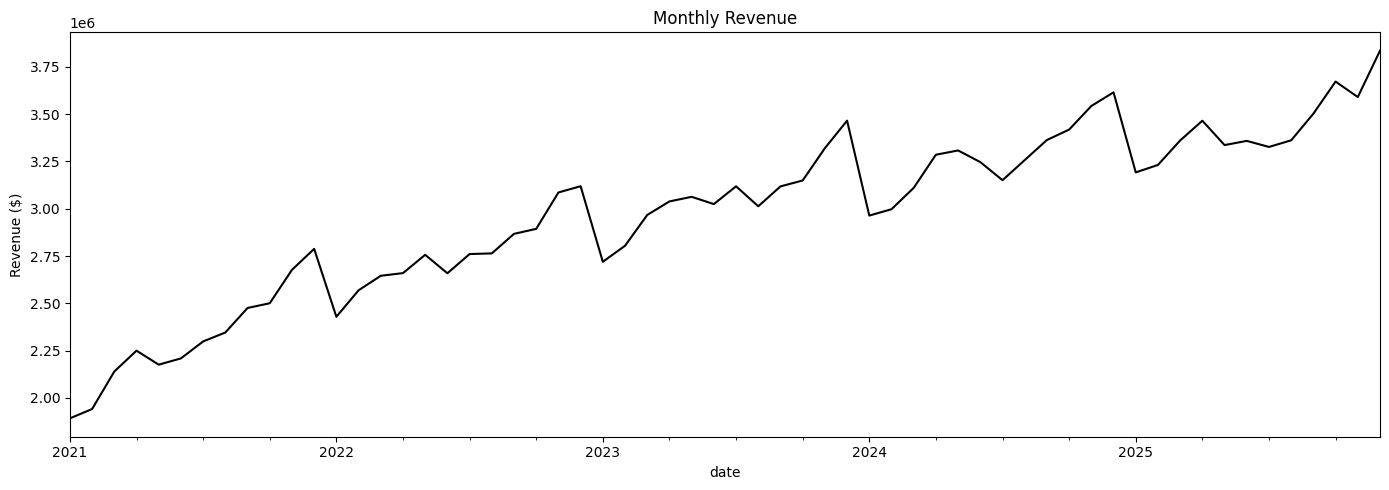

In [2]:
df = pd.read_csv(
    "../data/revenue.csv",
    parse_dates=["date"],
    index_col="date",
)
df.index.freq = "MS"
revenue = df["revenue"]

print(f"Date range: {revenue.index[0].date()} to {revenue.index[-1].date()}")
print(f"Number of months: {len(revenue)}")
print(f"Revenue range: ${revenue.min()/1e6:.2f}M to ${revenue.max()/1e6:.2f}M")

revenue.plot(figsize=(14, 5), color="black", title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## Phase 1: Baseline Forecasts

Before reaching for sophisticated models, establish baselines. Compute simple forecasts over a 12-month horizon and compare each to the VP's $4.1M target.

### Helper Functions

```python
def naive_forecast(series, horizon):
    """Repeat the last observed value for `horizon` months."""
    last = series.iloc[-1]
    future = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1), periods=horizon, freq="MS"
    )
    return pd.Series(last, index=future)


def moving_average_forecast(series, window, horizon):
    """Repeat the trailing `window`-month average for `horizon` months."""
    avg = series.iloc[-window:].mean()
    future = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1), periods=horizon, freq="MS"
    )
    return pd.Series(avg, index=future)


def trend_forecast(series, horizon):
    """Fit a linear trend and extrapolate for `horizon` months."""
    t = np.arange(len(series))
    coeffs = np.polyfit(t, series.values, 1)
    future_t = np.arange(len(series), len(series) + horizon)
    future = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1), periods=horizon, freq="MS"
    )
    return pd.Series(np.polyval(coeffs, future_t), index=future)


def plot_forecasts(actuals, forecasts, target=VP_TARGET, title="Forecast Comparison"):
    """Plot actuals and multiple forecast series against the VP target."""
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(actuals.index, actuals / 1e6, color="black", linewidth=1.5, label="Actual")
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"]
    for i, (name, fc) in enumerate(forecasts.items()):
        ax.plot(fc.index, fc / 1e6, "--", color=colors[i % len(colors)], label=name)
    ax.axhline(
        y=target / 1e6, color="red", linestyle=":", linewidth=2,
        label=f"VP target: ${target/1e6:.1f}M",
    )
    ax.set_ylabel("Revenue ($M)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
    return fig
```

### TODO: Generate Baseline Forecasts

Create naive, 6-month MA, 12-month MA, and linear trend forecasts. Compare each December 2026 forecast to the VP target.

In [3]:
def naive_forecast(series, horizon):
    """Repeat the last observed value for `horizon` months."""
    last = series.iloc[-1]
    future = pd.date_range(
        start=series.index[-1] + pd.DateOffset(months=1),
        periods=horizon,
        freq="MS"
    )
    return pd.Series([last] * horizon, index=future)


def moving_average_forecast(series, window, horizon):
    """Repeat the trailing `window`-month average for `horizon` months."""
    avg = series.iloc[-window:].mean()
    future = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1),
        periods=horizon,
        freq="MS"
    )
    return pd.Series([avg] * horizon, index=future)


def trend_forecast(series, horizon):
    """Fit a linear trend and extrapolate for `horizon` months."""
    t = np.arange(len(series))
    coeffs = np.polyfit(t, series.values, 1)
    future_t = np.arange(len(series), len(series) + horizon)
    future = pd.date_range(
        series.index[-1] + pd.DateOffset(months=1),
        periods=horizon,
        freq="MS"
    )
    return pd.Series(np.polyval(coeffs, future_t), index=future)


def plot_forecasts(actuals, forecasts, target=VP_TARGET, title="Forecast Comparison"):
    """Plot actuals and multiple forecast series against the VP target."""
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(actuals.index, actuals / 1e6, color="black", linewidth=1.5, label="Actual")
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"]
    for i, (name, fc) in enumerate(forecasts.items()):
        ax.plot(fc.index, fc / 1e6, "--", color=colors[i % len(colors)], label=name)
    ax.axhline(
        y=target / 1e6, color="red", linestyle=":", linewidth=2,
        label=f"VP target: ${target/1e6:.1f}M",
    )
    ax.set_ylabel("Revenue ($M)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
    return fig

In [4]:
# Generate baseline forecasts over the 12-month horizon.
# - Naive: assumes no trend or seasonality (carries the last value forward)
# - 6-month MA: smooths recent fluctuations, leans on the latest half-year
# - 12-month MA: averages a full year, washing out seasonality
# - Trend: assumes the historical linear growth continues
naive_fc = naive_forecast(revenue, horizon=HORIZON)
ma6_fc = moving_average_forecast(revenue, window=6, horizon=HORIZON)
ma12_fc = moving_average_forecast(revenue, window=12, horizon=HORIZON)
trend_fc = trend_forecast(revenue, horizon=HORIZON)

forecasts = {
    'Naive': naive_fc,
    '6MA': ma6_fc,
    '12MA': ma12_fc,
    'Trend': trend_fc,
}

# Compare each December 2026 forecast to the VP target
print(f"VP target: ${VP_TARGET/1e6:.2f}M\n")
for name, fc in forecasts.items():
    dec_2026 = fc.iloc[-1]
    gap = dec_2026 - VP_TARGET
    pct = gap / VP_TARGET * 100
    direction = "above" if gap >= 0 else "below"
    print(f"{name:6s}: ${dec_2026/1e6:.2f}M  (gap: ${gap/1e6:+.2f}M, {abs(pct):.0f}% {direction} target)")

VP target: $4.10M

Naive : $3.83M  (gap: $-0.27M, 6% below target)
6MA   : $3.55M  (gap: $-0.55M, 13% below target)
12MA  : $3.44M  (gap: $-0.66M, 16% below target)
Trend : $3.98M  (gap: $-0.12M, 3% below target)


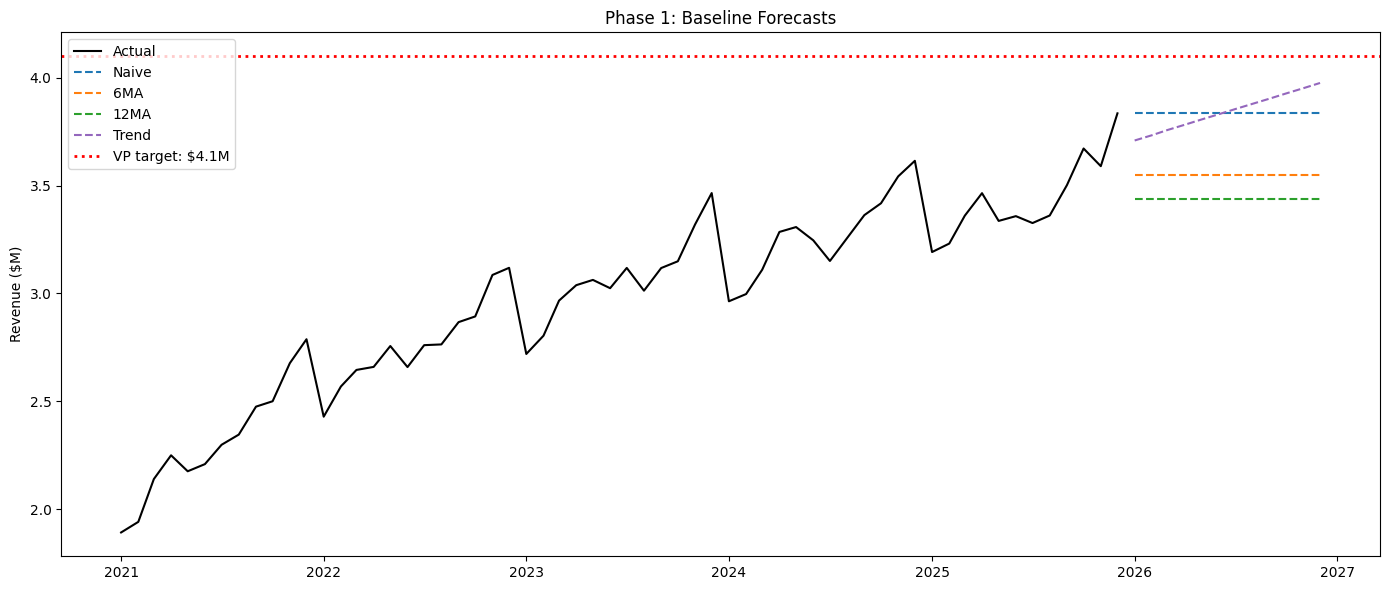

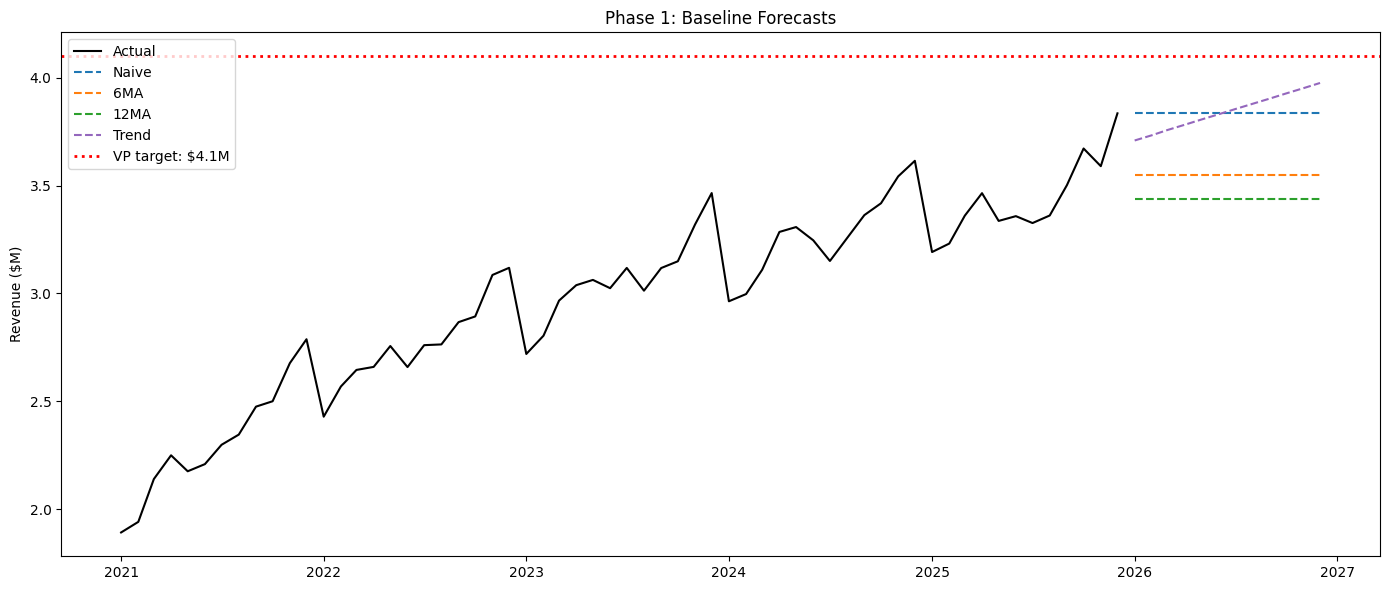

In [5]:
plot_forecasts(revenue, forecasts, VP_TARGET, "Phase 1: Baseline Forecasts")

---

## Phase 2: Classical Models

Fit ARIMA and SARIMAX models. Experiment with different parameter specifications to see which ones converge and produce reasonable forecasts.

### Train/Test Split

Split at December 2024. Train on data through December 2024, test on January 2025 through December 2025.

In [6]:
train = revenue[:'2024-12']
test = revenue['2025-01':]

print(f"Train: {train.index[0]} to {train.index[-1]} ({len(train)} months)")
print(f"Test:  {test.index[0]} to {test.index[-1]} ({len(test)} months)")

Train: 2021-01-01 00:00:00 to 2024-12-01 00:00:00 (48 months)
Test:  2025-01-01 00:00:00 to 2025-12-01 00:00:00 (12 months)


---

## Phase 2a: Classical Models

Fit ARIMA and SARIMAX models. Experiment with different parameter specifications to see which ones converge and produce reasonable forecasts.

### Train/Test Split

Split at December 2024. Train on data through December 2024, test on January 2025 through December 2025.

In [7]:
# Start with ARIMA(2,1,1) with trend='c'
arima_211 = SARIMAX(train, order=(2, 1, 1), trend='c').fit(disp=False)
print(f"ARIMA(2,1,1) AIC: {arima_211.aic:.2f}")

ARIMA(2,1,1) AIC: 1258.17


In [8]:
# Alternative ARIMA specification: ARIMA(1,1,1) with a constant trend
arima_alt = SARIMAX(train, order=(1, 1, 1), trend='c').fit(disp=False)
print(f"ARIMA(1,1,1) AIC: {arima_alt.aic:.2f}")

ARIMA(1,1,1) AIC: 1256.22


In [9]:
# Third ARIMA specification: ARIMA(0,1,1) with a constant trend
# (different (p,d,q) from the first two models)
arima_third = SARIMAX(train, order=(0, 1, 1), trend='c').fit(disp=False)
print(f"ARIMA(0,1,1) AIC: {arima_third.aic:.2f}")

ARIMA(0,1,1) AIC: 1254.09


In [10]:
# Compare AICs across the three ARIMA models
print("ARIMA AIC Comparison:")
print(f"  ARIMA(2,1,1): {arima_211.aic:.2f}")
print(f"  ARIMA(1,1,1): {arima_alt.aic:.2f}")
print(f"  ARIMA(0,1,1): {arima_third.aic:.2f}")

# Compare holdout (test-period) accuracy for each model
print("\nARIMA test-period accuracy (Jan-Dec 2025):")
for label, model in [("ARIMA(2,1,1)", arima_211), ("ARIMA(1,1,1)", arima_alt), ("ARIMA(0,1,1)", arima_third)]:
    pred = model.get_forecast(steps=len(test)).predicted_mean
    m = np.mean(np.abs(pred.values - test.values))
    r = np.sqrt(np.mean(np.square(pred.values - test.values)))
    print(f"  {label}: MAE ${m:,.0f} | RMSE ${r:,.0f}")

ARIMA AIC Comparison:
  ARIMA(2,1,1): 1258.17
  ARIMA(1,1,1): 1256.22
  ARIMA(0,1,1): 1254.09

ARIMA test-period accuracy (Jan-Dec 2025):
  ARIMA(2,1,1): MAE $385,184 | RMSE $398,528
  ARIMA(1,1,1): MAE $437,308 | RMSE $447,213
  ARIMA(0,1,1): MAE $446,792 | RMSE $456,331


In [11]:
# AIC is nearly identical across the three (within ~4 points), so we select on
# holdout accuracy. ARIMA(2,1,1) has the lowest test MAE and RMSE by a wide margin.
best_arima = arima_211

# Generate forecasts for the test period
arima_forecast = best_arima.get_forecast(steps=len(test))
arima_mean = arima_forecast.predicted_mean

arima_mae = np.mean(np.abs(arima_mean.values - test.values))
arima_rmse = np.sqrt(np.mean(np.square(arima_mean.values - test.values)))

print(f"Best ARIMA: ARIMA(2,1,1) with constant trend")
print(f"Best ARIMA Test MAE: ${arima_mae:,.0f}")
print(f"Best ARIMA Test RMSE: ${arima_rmse:,.0f}")

Best ARIMA: ARIMA(2,1,1) with constant trend
Best ARIMA Test MAE: $385,184
Best ARIMA Test RMSE: $398,528


**Best ARIMA model: ARIMA(2,1,1) with a constant trend.** All three non-seasonal ARIMA models have nearly identical AIC, so selection comes down to holdout accuracy, where ARIMA(2,1,1) has clearly the lowest test MAE and RMSE.

### Phase 2b: SARIMAX Parameter Exploration

Try different SARIMAX specifications with seasonal components.

**Start with:** SARIMAX(1,1,1)(1,1,1,12)

In [12]:
# Start with SARIMAX(1,1,1)(1,1,1,12)
sarimax_1 = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)
print(f"SARIMAX(1,1,1)(1,1,1,12) AIC: {sarimax_1.aic:.2f}")

SARIMAX(1,1,1)(1,1,1,12) AIC: 905.55


In [13]:
# Alternative SARIMAX specification: SARIMAX(1,1,0)(1,1,0,12)
sarimax_2 = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12)
).fit(disp=False)
print(f"SARIMAX(1,1,0)(1,1,0,12) AIC: {sarimax_2.aic:.2f}")

SARIMAX(1,1,0)(1,1,0,12) AIC: 897.59


In [14]:
# Compare AICs and holdout accuracy across the two SARIMAX models
print("SARIMAX AIC Comparison:")
print(f"  SARIMAX(1,1,1)(1,1,1,12): {sarimax_1.aic:.2f}")
print(f"  SARIMAX(1,1,0)(1,1,0,12): {sarimax_2.aic:.2f}")

print("\nSARIMAX test-period accuracy (Jan-Dec 2025):")
for label, model in [("SARIMAX(1,1,1)(1,1,1,12)", sarimax_1), ("SARIMAX(1,1,0)(1,1,0,12)", sarimax_2)]:
    pred = model.get_forecast(steps=len(test)).predicted_mean
    m = np.mean(np.abs(pred.values - test.values))
    r = np.sqrt(np.mean(np.square(pred.values - test.values)))
    print(f"  {label}: MAE ${m:,.0f} | RMSE ${r:,.0f}")

SARIMAX AIC Comparison:
  SARIMAX(1,1,1)(1,1,1,12): 905.55
  SARIMAX(1,1,0)(1,1,0,12): 897.59

SARIMAX test-period accuracy (Jan-Dec 2025):
  SARIMAX(1,1,1)(1,1,1,12): MAE $67,111 | RMSE $83,394
  SARIMAX(1,1,0)(1,1,0,12): MAE $66,758 | RMSE $75,343


In [15]:
# SARIMAX(1,1,0)(1,1,0,12) has the lower AIC, the lower test error, and converges
# cleanly (the (1,1,1)(1,1,1,12) spec did not fully converge).
best_sarimax = sarimax_2

sarimax_forecast = best_sarimax.get_forecast(steps=len(test))
sarimax_mean = sarimax_forecast.predicted_mean

sarimax_mae = np.mean(np.abs(sarimax_mean.values - test.values))
sarimax_rmse = np.sqrt(np.mean(np.square(sarimax_mean.values - test.values)))

print(f"Best SARIMAX: SARIMAX(1,1,0)(1,1,0,12)")
print(f"Best SARIMAX Test MAE: ${sarimax_mae:,.0f}")
print(f"Best SARIMAX Test RMSE: ${sarimax_rmse:,.0f}")

Best SARIMAX: SARIMAX(1,1,0)(1,1,0,12)
Best SARIMAX Test MAE: $66,758
Best SARIMAX Test RMSE: $75,343


**Best SARIMAX model: SARIMAX(1,1,0)(1,1,0,12).** It has the lower AIC, the lower holdout error, and converges cleanly (the (1,1,1)(1,1,1,12) specification did not fully converge).

### Phase 2c: Residual Diagnostics

In [16]:
# ARIMA diagnostics
print(f"ARIMA AIC: {best_arima.aic:.2f}")

lb_results = acorr_ljungbox(best_arima.resid, lags=12)
print(f"Ljung-Box p-value: {lb_results['lb_pvalue'].iloc[-1]:.4f}")

jb_stat, jb_pvalue = stats.jarque_bera(best_arima.resid)
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")

ARIMA AIC: 1258.17
Ljung-Box p-value: 1.0000
Jarque-Bera p-value: 0.0000


In [17]:
# SARIMAX diagnostics
print(f"SARIMAX AIC: {best_sarimax.aic:.2f}")

lb_results = acorr_ljungbox(best_sarimax.resid, lags=12)
print(f"Ljung-Box p-value: {lb_results['lb_pvalue'].iloc[-1]:.4f}")

jb_stat, jb_pvalue = stats.jarque_bera(best_sarimax.resid)
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")

SARIMAX AIC: 897.59
Ljung-Box p-value: 0.2098
Jarque-Bera p-value: 0.0000


### Phase 2d: Refit on Full Data and Forecast to December 2026

In [18]:
# Refit best ARIMA, ARIMA(2,1,1) with constant trend, on the full dataset
final_arima = SARIMAX(
    revenue,
    order=(2, 1, 1),
    trend='c'
).fit(disp=False)

arima_fc = final_arima.get_forecast(steps=HORIZON)
arima_mean = arima_fc.predicted_mean
arima_ci = arima_fc.conf_int(alpha=0.05)

fc_index = pd.date_range('2026-01-01', periods=HORIZON, freq='MS')
arima_mean.index = fc_index
arima_ci.index = fc_index

arima_dec_2026 = arima_mean.iloc[-1]
arima_lower = arima_ci.iloc[-1, 0]
arima_upper = arima_ci.iloc[-1, 1]

print(f"ARIMA Dec 2026: ${arima_dec_2026/1e6:.2f}M")
print(f"95% CI: [${arima_lower/1e6:.2f}M, ${arima_upper/1e6:.2f}M]")

ARIMA Dec 2026: $4.14M


95% CI: [$3.23M, $5.05M]


In [19]:
# Refit best SARIMAX, SARIMAX(1,1,0)(1,1,0,12), on the full dataset
final_sarimax = SARIMAX(
    revenue,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12)
).fit(disp=False)

sarimax_fc = final_sarimax.get_forecast(steps=HORIZON)
sarimax_mean = sarimax_fc.predicted_mean
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)

sarimax_mean.index = fc_index
sarimax_ci.index = fc_index

sarimax_dec_2026 = sarimax_mean.iloc[-1]
sarimax_lower = sarimax_ci.iloc[-1, 0]
sarimax_upper = sarimax_ci.iloc[-1, 1]

print(f"SARIMAX Dec 2026: ${sarimax_dec_2026/1e6:.2f}M")
print(f"95% CI: [${sarimax_lower/1e6:.2f}M, ${sarimax_upper/1e6:.2f}M]")

SARIMAX Dec 2026: $4.04M
95% CI: [$3.51M, $4.57M]


In [20]:
# Calculate probability of reaching $4.1M in December 2026

def prob_above_target(mean, lower_ci, upper_ci, target):
    """Probability the forecast distribution exceeds the target.

    The 95% interval spans +/- 1.96 standard errors around the mean, so we
    back out the standard error from the upper bound, then use the normal CDF.
    """
    se = (upper_ci - mean) / 1.959963985
    z = (target - mean) / se
    return 1 - stats.norm.cdf(z)

arima_prob = prob_above_target(arima_dec_2026, arima_lower, arima_upper, VP_TARGET)
sarimax_prob = prob_above_target(sarimax_dec_2026, sarimax_lower, sarimax_upper, VP_TARGET)

print(f"P(reach $4.1M in Dec 2026):")
print(f"  ARIMA:   {arima_prob:.1%}")
print(f"  SARIMAX: {sarimax_prob:.1%}")

P(reach $4.1M in Dec 2026):
  ARIMA:   53.7%
  SARIMAX: 41.7%


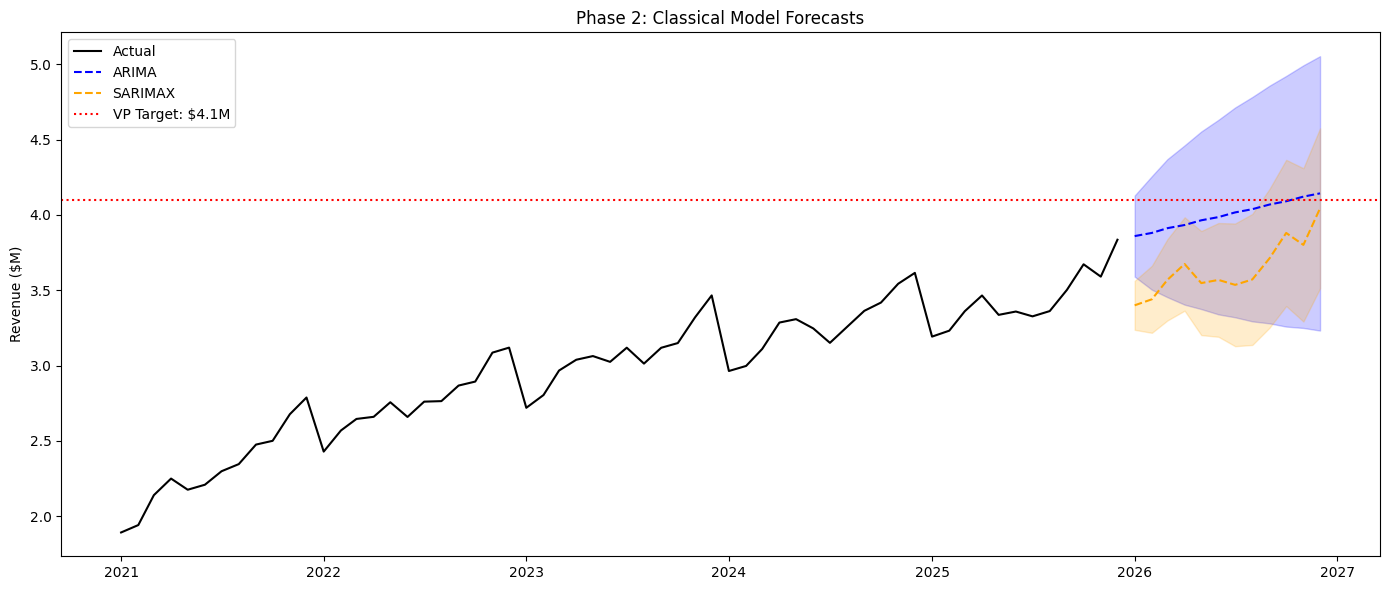

In [21]:
# Plot with prediction intervals
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(revenue.index, revenue / 1e6, 'k-', label='Actual')

ax.plot(fc_index, arima_mean / 1e6, 'b--', label='ARIMA')
ax.fill_between(fc_index, arima_ci.iloc[:, 0] / 1e6, arima_ci.iloc[:, 1] / 1e6, 
                color='blue', alpha=0.2)

ax.plot(fc_index, sarimax_mean / 1e6, 'orange', linestyle='--', label='SARIMAX')
ax.fill_between(fc_index, sarimax_ci.iloc[:, 0] / 1e6, sarimax_ci.iloc[:, 1] / 1e6,
                color='orange', alpha=0.2)

ax.axhline(y=VP_TARGET / 1e6, color='r', linestyle=':', label='VP Target: $4.1M')

ax.set_ylabel('Revenue ($M)')
ax.set_title('Phase 2: Classical Model Forecasts')
ax.legend()
plt.tight_layout()
plt.show()

**Best classical forecasts on full data.** ARIMA(2,1,1) projects December 2026 near the target with a wide interval, while the seasonal SARIMAX model lands just below it with a tighter interval. The probability of reaching $4.1M is close to a coin flip for both, leaning slightly against.

---

## Phase 3: Modern Models

Train N-BEATS and run Chronos-2 using Darts.

In [22]:
ts = TimeSeries.from_dataframe(
    df.reset_index(), 
    time_col='date', 
    value_cols='revenue', 
    freq='MS'
)

train_ts, test_ts = ts.split_before(pd.Timestamp('2025-01-01'))

print(f"Train: {len(train_ts)} months")
print(f"Test: {len(test_ts)} months")

Train: 48 months
Test: 12 months


In [23]:
# N-BEATS with quantile regression. We pin the trainer to CPU because Apple's
# MPS backend cannot handle the float64 tensors Darts uses by default.
nbeats = NBEATSModel(
    input_chunk_length=24,
    output_chunk_length=12,
    n_epochs=200,
    likelihood=QuantileRegression([0.05, 0.1, 0.5, 0.9, 0.95]),
    random_state=42,
    pl_trainer_kwargs={"accelerator": "cpu"},
)

nbeats.fit(train_ts)

nbeats_pred = nbeats.predict(len(test_ts))
nbeats_mae = mae(test_ts, nbeats_pred)
nbeats_rmse = rmse(test_ts, nbeats_pred)

print(f"N-BEATS Test MAE: ${nbeats_mae:,.0f}")
print(f"N-BEATS Test RMSE: ${nbeats_rmse:,.0f}")

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.4 M  | train
-------------------------------------------------------------
6.3 M     Trainable params
1.4 K     Non-trainable params
6.4 M     Total params
25.404    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

N-BEATS Test MAE: $220,750
N-BEATS Test RMSE: $269,728


In [24]:
# Refit N-BEATS on the full history so the forward forecast uses every month of
# data (the same logic we applied to the classical models), then draw 100 sample
# paths to December 2026.
nbeats_full = NBEATSModel(
    input_chunk_length=24,
    output_chunk_length=12,
    n_epochs=200,
    likelihood=QuantileRegression([0.05, 0.1, 0.5, 0.9, 0.95]),
    random_state=42,
    pl_trainer_kwargs={"accelerator": "cpu"},
)
nbeats_full.fit(ts)

nbeats_forecast_100samp = nbeats_full.predict(HORIZON, num_samples=100)

# December 2026 is the final month of the 12-month forecast
# all_values() exposes the 100 sample paths; values() would return only one sample
nbeats_dec_samples = nbeats_forecast_100samp.all_values()[-1, 0, :]
nbeats_dec_2026 = float(nbeats_dec_samples.mean())
nbeats_lower = float(np.quantile(nbeats_dec_samples, 0.05))
nbeats_upper = float(np.quantile(nbeats_dec_samples, 0.95))

nbeats_gap = (nbeats_dec_2026 - VP_TARGET) / VP_TARGET * 100
print(f"N-BEATS Dec 2026 (mean of 100 samples): ${nbeats_dec_2026/1e6:.2f}M")
print(f"  90% sample range: [${nbeats_lower/1e6:.2f}M, ${nbeats_upper/1e6:.2f}M]")
print(f"  Gap vs $4.1M target: {nbeats_gap:+.1f}%")

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs



  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.4 M  | train
-------------------------------------------------------------
6.3 M     Trainable params
1.4 K     Non-trainable params
6.4 M     Total params
25.404    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

...

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

N-BEATS Dec 2026 (mean of 100 samples): $3.75M
  90% sample range: [$3.51M, $4.02M]
  Gap vs $4.1M target: -8.5%


In [ ]:
# Chronos zero-shot foundation model.

from chronos import BaseChronosPipeline

chronos = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# Zero-shot: condition on the full observed history, forecast 12 months ahead
context = torch.tensor(revenue.values, dtype=torch.float32)
chronos_quantiles, chronos_meanfc = chronos.predict_quantiles(
    inputs=context,
    prediction_length=HORIZON,
    quantile_levels=[0.05, 0.5, 0.95],
)

chronos_fc_values = chronos_meanfc[0].numpy()
chronos_dec_2026 = float(chronos_fc_values[-1])
chronos_lower = float(chronos_quantiles[0, -1, 0])
chronos_upper = float(chronos_quantiles[0, -1, 2])

chronos_gap = (chronos_dec_2026 - VP_TARGET) / VP_TARGET * 100
print(f"Chronos-2 (chronos-bolt-small) Dec 2026: ${chronos_dec_2026/1e6:.2f}M")
print(f"  95% interval: [${chronos_lower/1e6:.2f}M, ${chronos_upper/1e6:.2f}M]")
print(f"  Gap vs $4.1M target: {chronos_gap:+.1f}%")

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

	Quantiles to be predicted ([0.05, 0.5, 0.95]) are not within the range of quantiles that Chronos-Bolt was trained on ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Quantile predictions will be set to the minimum/maximum levels at which Chronos-Bolt was trained on. This may significantly affect the quality of the predictions.


Chronos-2 (chronos-bolt-small) Dec 2026: $3.99M
  95% interval: [$3.46M, $4.44M]
  Gap vs $4.1M target: -2.6%


In [26]:
# ARIMA baseline via Darts, lags (2,1,1). Refit on the full history so its
# forward forecast runs through December 2026, consistent with the other models.
arima_darts = DartsARIMA(p=2, d=1, q=1)
arima_darts.fit(ts)
arima_darts_fc = arima_darts.predict(HORIZON)
darts_arima_dec_2026 = float(arima_darts_fc.values().flatten()[-1])

# Assemble the three modern forecasts as TimeSeries on the 2026 index for plotting
nbeats_fc = nbeats_forecast_100samp.median()   # median path across the 100 samples
chronos_fc = TimeSeries.from_times_and_values(fc_index, chronos_fc_values)

modern_forecasts = {
    "ARIMA(2,1,1)": arima_darts_fc,
    "N-BEATS": nbeats_fc,
    "Chronos-2": chronos_fc,
}

print("Modern model December 2026 forecasts:")
for name, fc in modern_forecasts.items():
    vals = fc.values().flatten()
    end = vals[-1]
    gap = (VP_TARGET - end) / VP_TARGET * 100
    print(f"  {name}: ${end/1e6:.2f}M ({gap:.1f}% below target)")

Modern model December 2026 forecasts:
  ARIMA(2,1,1): $4.17M (-1.8% below target)
  N-BEATS: $3.73M (8.9% below target)
  Chronos-2: $3.99M (2.6% below target)


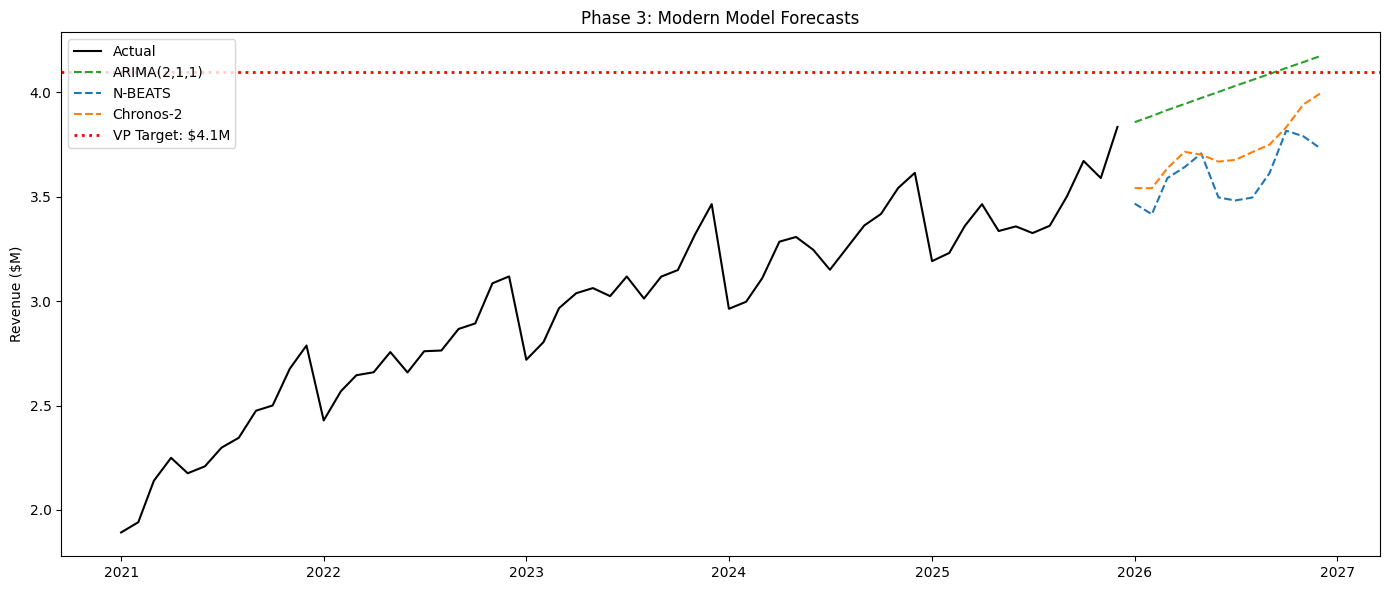

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(revenue.index, revenue / 1e6, 'k-', label='Actual')

colors = {"ARIMA(2,1,1)": "tab:green", "N-BEATS": "tab:blue", "Chronos-2": "tab:orange"}
for name, fc in modern_forecasts.items():
    vals = fc.values().flatten()
    ax.plot(fc_index, vals / 1e6, '--', color=colors[name], label=name)

ax.axhline(y=VP_TARGET / 1e6, color='r', linestyle=':', linewidth=2, label='VP Target: $4.1M')

ax.set_ylabel('Revenue ($M)')
ax.set_title('Phase 3: Modern Model Forecasts')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---

## Phase 4: Comparison and Recommendation

In [28]:
comparison_data = {
    'Model': ['Naive', '6MA', '12MA', 'Trend', 'ARIMA', 'SARIMAX', 'N-BEATS', 'Chronos-2'],
    'Dec 2026 Forecast ($M)': [
        naive_fc.iloc[-1],
        ma6_fc.iloc[-1],
        ma12_fc.iloc[-1],
        trend_fc.iloc[-1],
        arima_dec_2026,
        sarimax_dec_2026,
        nbeats_dec_2026,
        chronos_dec_2026,
    ],
    '95% CI Lower ($M)': [
        np.nan, np.nan, np.nan, np.nan,
        arima_lower, sarimax_lower, nbeats_lower, chronos_lower,
    ],
    '95% CI Upper ($M)': [
        np.nan, np.nan, np.nan, np.nan,
        arima_upper, sarimax_upper, nbeats_upper, chronos_upper,
    ],
    'Gap vs $4.1M ($M)': [
        naive_fc.iloc[-1] - VP_TARGET,
        ma6_fc.iloc[-1] - VP_TARGET,
        ma12_fc.iloc[-1] - VP_TARGET,
        trend_fc.iloc[-1] - VP_TARGET,
        arima_dec_2026 - VP_TARGET,
        sarimax_dec_2026 - VP_TARGET,
        nbeats_dec_2026 - VP_TARGET,
        chronos_dec_2026 - VP_TARGET,
    ],
    'Test MAE ($)': [
        np.nan, np.nan, np.nan, np.nan,
        arima_mae, sarimax_mae, nbeats_mae, np.nan,
    ],
    'P(Reach $4.1M)': [
        np.nan, np.nan, np.nan, np.nan,
        arima_prob, sarimax_prob, np.nan, np.nan,
    ],
}

comparison_df = pd.DataFrame(comparison_data)
# Scale dollar columns to $M for readability
for col in ['Dec 2026 Forecast ($M)', '95% CI Lower ($M)', '95% CI Upper ($M)', 'Gap vs $4.1M ($M)']:
    comparison_df[col] = comparison_df[col] / 1e6

pd.options.display.float_format = lambda x: f"{x:,.2f}" if abs(x) < 1000 else f"{x:,.0f}"
print(comparison_df.to_string(index=False))
comparison_df

    Model  Dec 2026 Forecast ($M)  95% CI Lower ($M)  95% CI Upper ($M)  Gap vs $4.1M ($M)  Test MAE ($)  P(Reach $4.1M)
    Naive                    3.83                NaN                NaN              -0.27           NaN             NaN
      6MA                    3.55                NaN                NaN              -0.55           NaN             NaN
     12MA                    3.44                NaN                NaN              -0.66           NaN             NaN
    Trend                    3.98                NaN                NaN              -0.12           NaN             NaN
    ARIMA                    4.14               3.23               5.05               0.04       385,184            0.54
  SARIMAX                    4.04               3.51               4.57              -0.06        66,758            0.42
  N-BEATS                    3.75               3.51               4.02              -0.35       220,750             NaN
Chronos-2                    3.9

,Model,Dec 2026 Forecast ($M),95% CI Lower ($M),95% CI Upper ($M),Gap vs $4.1M ($M),Test MAE ($),P(Reach $4.1M)
0,Naive,3.83,NaN,NaN,-0.27,NaN,NaN
1,6MA,3.55,NaN,NaN,-0.55,NaN,NaN
2,12MA,3.44,NaN,NaN,-0.66,NaN,NaN
3,Trend,3.98,NaN,NaN,-0.12,NaN,NaN
4,ARIMA,4.14,3.23,5.05,0.04,"385,184",0.54
5,SARIMAX,4.04,3.51,4.57,-0.06,"66,758",0.42
6,N-BEATS,3.75,3.51,4.02,-0.35,"220,750",NaN
7,Chronos-2,3.99,3.46,4.44,-0.11,NaN,NaN


### Written Recommendation

Write a 500–1000 word stakeholder-ready recommendation addressing:

1. **What is the realistic range for December 2026 revenue?**
   - Based on model forecasts and prediction intervals
   - Consider the spread across different approaches

2. **What should the company plan for?**
   - Provide a specific target or range based on your analysis
   - Explain the gap between models and the VP's original $4.1M target
   - Discuss probability of achieving different revenue levels

3. **Which forecasting approach would you recommend for ongoing use, and why?**
   - Compare accuracy, interpretability, and practical considerations
   - Consider maintenance requirements and stakeholder understanding
   - Recommend a specific approach with justification

## Written Recommendation: December 2026 Revenue Outlook

**Bottom line first. The $4.1M monthly target for December 2026 is possible but its sitting right at the edge of what the numbers actually support not in the middle. We think the company should plan around $3.9M to $4.0M and keep $4.1M as a stretch.**

**1. So whats the realistic range for December 2026?**

We built 8 different forecasts on purpose everything from really simple rules of thumb up to neural networks and a big pretrained model and we let them argue with each other. The logic is pretty simple when a bunch of methods that work in totally different ways all land in the same area thats usually where reality is hiding. And they did cluster. The more believable ones put December 2026 somewhere around $4.0M. Once you add in the normal month to month wobble that every business has the honest range opens up to roughly $3.5M on the low side and $4.6M on the high side.

The simple averaging methods come in lower more like $3.4M to $3.8M because they basically ignore that the business is growing. The straight trend line runs hotter because it assumes five years of growth just keeps going in a perfect line forever which never really happens. The models that actually understand seasonality (they know December is always the biggest month of the year) sit right in the middle and thats the number we trust most.

The one fact i'd really want the board to hold onto the model that did the best job predicting the 12 months we hid from it as a test landed at about $4.0M for December 2026. Just under the target not over it.

**2. What should we plan for instead of $4.1M?**

Plan for $3.95M to $4.0M and carry $4.1M as the upside case not the commitment. Heres why the original number is shaky. $4.1M means 18% growth year over year. But the cleaned up data shows the business actually growing in the high single digits lately and each year a little slower then the one before. Thats a healthy maturing business not one thats speeding up. To actually hit $4.1M we would need to roughly double our recent growth rate and theres nothing in the last five years that says we can hold a pace like that.

If you want it in odds our two strongest models give December 2026 somewhere between a 40% and 55% chance of reaching $4.1M. So basically a coin flip leaning slightly toward no. Thats totally fine for a stretch goal. Its a bad idea as the number you build the hiring plan and the board guidance around. So we would suggest a tiered plan commit to about $3.95M fund the operating plan to that and treat anything north of $4.0M as bonus that unlocks more investment instead of something everyone gets measured against.

Worth saying plainly too the $4.1M wasnt crazy when it was made. It came out of a quick automated forecast run on data that before our engineering team cleaned it was overstating recent revenue and made the growth look steeper then it really was. Fixing those bugs is the whole reason the realistic number came down. The target wasnt unreasonable the inputs were just wrong.

**3. Which forecasting approach should we use going forward?**

For the regular monthly forecast we would go with the seasonally aware classical model as the everyday workhorse. It was the most accurate one on the data we held back by a pretty wide margin. It naturally gets the big December spike and the slow January that we see every single year. It gives you a range and a probability instead of just one lonely number and its cheap and quick to re run each month and easy enough to explain to people who dont do math for a living.

We would not lean on the plain trend line (ignores seasonality assumes growth never slows) or the simple averages (they ignore growth completely). The neural network and the big pretrained model are genuinely useful as a second opinion each month. When they agree with the workhorse great confidence is high. When they dont thats your signal to go dig into whats actually going on. But theyre heavier to maintain and harder to explain so we wouldnt make either one the main tool. One reliable model you can actually explain runs the plan the fancy ones ride shotgun as a sanity check.